In [2]:
import pandas as pd
from scipy import stats
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
EV_population = pd.read_csv("Electric_Vehicle_Population_Data.csv")

In [4]:
fuel_stations = pd.read_csv("alt_fuel_stations.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_38540\3407117380.py:1: DtypeWarning: Columns (20,31,40,46,69,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  fuel_stations = pd.read_csv("alt_fuel_stations.csv")


In [5]:
# Summary of the data
EV_population.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  object 
 1   County                                             280821 non-null  object 
 2   City                                               280821 non-null  object 
 3   State                                              280833 non-null  object 
 4   Postal Code                                        280821 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  object 
 7   Model                                              280833 non-null  object 
 8   Electric Vehicle Type                              280833 non-null  object

In [6]:
# First 5 rows of the data
EV_population.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [7]:
# Basic Statistics of numeric columns
EV_population.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,280821.000000,280833.000000,280821.000000,280130.000000,2.808330e+05,2.808210e+05
mean,98175.409538,2022.111643,38.757846,28.819352,2.470600e+08,5.297039e+10
std,2591.070456,3.064528,77.903581,14.907410,6.325326e+07,1.654845e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.240730e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.642395e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.803006e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [8]:
# Convert column names to lowercase
EV_population.columns = EV_population.columns.str.lower()
EV_population.columns

Index(['vin (1-10)', 'county', 'city', 'state', 'postal code', 'model year',
       'make', 'model', 'electric vehicle type',
       'clean alternative fuel vehicle (cafv) eligibility', 'electric range',
       'legislative district', 'dol vehicle id', 'vehicle location',
       'electric utility', '2020 census tract'],
      dtype='object')

In [9]:
# Changing column names
EV_population.rename(columns={'vin (1-10)': 'vin', 'postal code': 'postal_code', 'model year': 'model_year', 'electric vehicle type': 'ev_type', 
                              'clean alternative fuel vehicle (cafv) eligibility': 'cafv_eligibility', 'electric range': 'electric_range', 'legislative district': 'legislative_district', 
                              'dol vehicle id': 'dol_id', 'vehicle location': 'vehicle_location', 'electric utility': 'electric_utility', '2020 census tract': '2020_census_tract'}, inplace=True)
EV_population.columns

Index(['vin', 'county', 'city', 'state', 'postal_code', 'model_year', 'make',
       'model', 'ev_type', 'cafv_eligibility', 'electric_range',
       'legislative_district', 'dol_id', 'vehicle_location',
       'electric_utility', '2020_census_tract'],
      dtype='object')

In [10]:
# Counts missing values 
EV_population.isnull().sum()

vin                       0
county                   12
city                     12
state                     0
postal_code              12
model_year                0
make                      0
model                     0
ev_type                   0
cafv_eligibility          0
electric_range           12
legislative_district    703
dol_id                    0
vehicle_location         20
electric_utility         12
2020_census_tract        12
dtype: int64

In [11]:
# Drops rows with missing values
EV_population = EV_population.dropna(subset=['county', 'city', 'postal_code', 'electric_range', 'legislative_district', 'vehicle_location', 'electric_utility', '2020_census_tract'])
# Counts missing values 
EV_population.isnull().sum()

vin                     0
county                  0
city                    0
state                   0
postal_code             0
model_year              0
make                    0
model                   0
ev_type                 0
cafv_eligibility        0
electric_range          0
legislative_district    0
dol_id                  0
vehicle_location        0
electric_utility        0
2020_census_tract       0
dtype: int64

In [12]:
# Classifying Column Datatypes
# Postal Code → object (remove .0 issue)
EV_population["postal_code"] = (
    EV_population["postal_code"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

# Model Year → integer
EV_population["model_year"] = pd.to_numeric(
    EV_population["model_year"], errors="coerce"
).astype("Int64")

# CAFV Eligibility → category
EV_population["cafv_eligibility"] = EV_population["cafv_eligibility"].astype("category")

# Legislative District → category
EV_population["legislative_district"] = EV_population["legislative_district"].astype("category")

# 2020 Census Tract → Object (ID, not numeric)
EV_population["2020_census_tract"] = (
    EV_population["2020_census_tract"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

# Conversion of object to category
EV_population[
    [
        "county",
        "city",
        "state",
        "make",
        "model",
        "ev_type",
        "electric_utility"
    ]
] = EV_population[
    [
        "county",
        "city",
        "state",
        "make",
        "model",
        "ev_type",
        "electric_utility"
    ]
].astype("category")

EV_population.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280110 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   vin                   280110 non-null  object  
 1   county                280110 non-null  category
 2   city                  280110 non-null  category
 3   state                 280110 non-null  category
 4   postal_code           280110 non-null  object  
 5   model_year            280110 non-null  Int64   
 6   make                  280110 non-null  category
 7   model                 280110 non-null  category
 8   ev_type               280110 non-null  category
 9   cafv_eligibility      280110 non-null  category
 10  electric_range        280110 non-null  float64 
 11  legislative_district  280110 non-null  category
 12  dol_id                280110 non-null  int64   
 13  vehicle_location      280110 non-null  object  
 14  electric_utility      280110 non-null  ca

In [13]:
# Counts no. of unique values in a column
EV_population['state'].value_counts()

state
WA    280110
Name: count, dtype: int64

In [14]:
# Removes the column
EV_population = EV_population.drop('state', axis=1)

In [15]:
# Counts no. of unique values in a column
EV_population['county'].value_counts()

county
King            138268
Snohomish        35136
Pierce           23040
Clark            17301
Thurston         10220
Kitsap            9563
Spokane           7863
Whatcom           6872
Benton            4017
Skagit            3343
Island            3054
Yakima            1961
Chelan            1784
Clallam           1697
Jefferson         1512
Cowlitz           1493
Mason             1436
San Juan          1290
Lewis             1240
Franklin          1215
Grant             1130
Grays Harbor      1090
Kittitas          1085
Walla Walla        791
Douglas            622
Whitman            561
Klickitat          492
Okanogan           431
Stevens            369
Pacific            344
Skamania           274
Adams              126
Asotin             111
Pend Oreille       108
Wahkiakum           97
Lincoln             88
Ferry               55
Columbia            26
Garfield             5
Name: count, dtype: int64

In [16]:
# Counts no. of unique values in a column
EV_population['make'].value_counts()

make
TESLA                     114465
CHEVROLET                  19379
NISSAN                     16131
FORD                       15389
KIA                        14083
TOYOTA                     11938
BMW                        11622
HYUNDAI                    10556
RIVIAN                      8929
VOLKSWAGEN                  7496
VOLVO                       7440
JEEP                        6738
AUDI                        5941
CHRYSLER                    3663
MERCEDES-BENZ               3342
HONDA                       3136
SUBARU                      2791
CADILLAC                    2477
PORSCHE                     2036
LEXUS                       1661
POLESTAR                    1615
MAZDA                       1545
MITSUBISHI                  1280
MINI                        1222
FIAT                         847
DODGE                        827
LUCID                        740
GMC                          557
GENESIS                      508
LINCOLN                      449
ACURA

In [17]:
# Counts no. of unique values in a column
EV_population['model_year'].value_counts()

model_year
2023    60166
2024    49404
2025    36813
2022    29819
2021    20674
2026    19660
2018    13920
2020    12003
2019    10754
2017     8379
2016     5054
2015     4380
2013     3910
2014     3165
2012     1362
2011      572
2027       24
2010       21
2008       19
2000        7
1999        2
2002        1
2003        1
Name: count, dtype: Int64

In [18]:
EV_population['ev_type'].value_counts()

ev_type
Battery Electric Vehicle (BEV)            224600
Plug-in Hybrid Electric Vehicle (PHEV)     55510
Name: count, dtype: int64

In [19]:
EV_population['model'].value_counts()

model
MODEL Y        60184
MODEL 3        37708
LEAF           13481
MODEL S         7709
BOLT EV         7693
               ...  
918                2
CONTINENTAL        2
WHEEGO             2
GRANCABRIO         1
RCV                1
Name: count, Length: 187, dtype: int64

In [20]:
EV_population['electric_utility'].value_counts()

electric_utility
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)                                               99786
PUGET SOUND ENERGY INC                                                                      59316
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)                                                46429
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA)                            16897
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY             12811
                                                                                            ...  
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF JEFFERSON COUNTY                                   1
BONNEVILLE POWER ADMINISTRATION||PENINSULA LIGHT COMPANY                                        1
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLALLAM COUNTY|PUD NO 1 OF JEFFERSON COUNTY        1
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF ASOTIN COUNTY||INLAND POWER & LIGHT COMPANY        1
BON

In [21]:
EV_population['city'].value_counts()

city
Seattle      43218
Bellevue     13705
Vancouver    10443
Redmond       9641
Bothell       9297
             ...  
Lamont           1
Laurier          1
Bnco             1
Waverly          1
Albion           1
Name: count, Length: 500, dtype: int64

In [22]:
# Checking for Duplicates
EV_population.duplicated().sum()

np.int64(0)

In [23]:
# First 5 rows of the data
EV_population.head()

,vin,county,city,postal_code,model_year,make,model,ev_type,cafv_eligibility,electric_range,legislative_district,dol_id,vehicle_location,electric_utility,2020_census_tract
0,1N4AZ0CP6D,King,Kirkland,98034,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033022203
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,98110,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,53035090902
2,5YJ3E1EBXJ,King,Seattle,98144,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033009000
3,ZFAFFAC45R,Thurston,Yelm,98597,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,53067012412
4,5YJYGDEE3L,King,Kent,98030,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029507


In [24]:
# Removes extra spaces and capitalizes properly
EV_population["city"] = EV_population["city"].str.strip().str.title()
EV_population["county"] = EV_population["county"].str.strip().str.title()
EV_population["make"] = EV_population["make"].str.upper()

In [25]:
# First 5 rows of the data
EV_population.head()

,vin,county,city,postal_code,model_year,make,model,ev_type,cafv_eligibility,electric_range,legislative_district,dol_id,vehicle_location,electric_utility,2020_census_tract
0,1N4AZ0CP6D,King,Kirkland,98034,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033022203
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,98110,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,53035090902
2,5YJ3E1EBXJ,King,Seattle,98144,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033009000
3,ZFAFFAC45R,Thurston,Yelm,98597,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,53067012412
4,5YJYGDEE3L,King,Kent,98030,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029507


In [26]:
# Saved cleaned data to csv file
EV_population.to_csv('Cleaned_EV_population.csv', index=False)

In [27]:
# Summary of the data
fuel_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87339 entries, 0 to 87338
Data columns (total 75 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Fuel Type Code                           87339 non-null  object 
 1   Station Name                             87338 non-null  object 
 2   Street Address                           87298 non-null  object 
 3   Intersection Directions                  25489 non-null  object 
 4   City                                     87336 non-null  object 
 5   State                                    87339 non-null  object 
 6   ZIP                                      87337 non-null  float64
 7   Plus4                                    0 non-null      float64
 8   Station Phone                            81787 non-null  object 
 9   Status Code                              87339 non-null  object 
 10  Expected Date                            2085 

In [28]:
fuel_stations.columns = (
    fuel_stations.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [29]:
fuel_stations.describe()

,zip,plus4,bd_blends,ng_fill_type_code,ng_psi,ev_level1_evse_num,ev_level2_evse_num,ev_dc_fast_count,latitude,longitude,...,cng_fill_type_code,cng_psi,cng_vehicle_class,lng_vehicle_class,rd_blends,rd_blends_(french),rd_blended_with_biodiesel,rd_maximum_biodiesel_level,cng_station_sells_renewable_natural_gas,lng_station_sells_renewable_natural_gas
count,87337.000000,0.0,0.0,0.0,0.0,682.000000,72819.00000,15694.000000,87339.000000,87339.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,55744.448115,NaN,NaN,NaN,NaN,4.401760,2.82348,4.703900,37.963574,-96.132926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,34124.090001,NaN,NaN,NaN,NaN,8.580954,4.91564,5.546999,5.075510,19.443186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,1.000000,1.00000,1.000000,17.995808,-176.636362,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,22932.000000,NaN,NaN,NaN,NaN,1.000000,2.00000,1.000000,34.054294,-117.872063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,59068.000000,NaN,NaN,NaN,NaN,2.000000,2.00000,3.000000,38.650481,-90.330758,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,91711.000000,NaN,NaN,NaN,NaN,4.000000,2.00000,6.000000,41.728104,-78.650138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,99926.000000,NaN,NaN,NaN,NaN,90.000000,379.00000,120.000000,64.852466,-65.650842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
fuel_stations.isnull().sum()

fuel_type_code                                 0
station_name                                   1
street_address                                41
intersection_directions                    61850
city                                           3
                                           ...  
cng_station_sells_renewable_natural_gas    87339
lng_station_sells_renewable_natural_gas    87339
maximum_vehicle_class                      71082
ev_workplace_charging                         20
funding_sources                            87130
Length: 75, dtype: int64

In [31]:
# Columns to drop
cols_to_drop = [
    "plus4", "bd_blends", "ng_fill_type_code", "ng_psi",
    "ev_other_info", "hydrogen_status_link", "ng_vehicle_class",
    "lpg_primary", "e85_blender_pump", "intersection_directions_(french)",
    "bd_blends_(french)", "hydrogen_is_retail", "cng_dispenser_num",
    "cng_on_site_renewable_source", "cng_total_compression_capacity",
    "cng_storage_capacity", "lng_on_site_renewable_source",
    "e85_other_ethanol_blends", "ev_pricing_(french)", "lpg_nozzle_types",
    "hydrogen_pressures", "hydrogen_standards", "cng_fill_type_code",
    "cng_psi", "cng_vehicle_class", "lng_vehicle_class",
    "rd_blends", "rd_blends_(french)", "rd_blended_with_biodiesel",
    "rd_maximum_biodiesel_level", "cng_station_sells_renewable_natural_gas",
    "lng_station_sells_renewable_natural_gas", "funding_sources",
    "access_days_time_(french)", "groups_with_access_code_(french)",
    "bd_blends", "ng_fill_type_code", "ng_psi",
    "intersection_directions", "expected_date",
    "cards_accepted", "owner_type_code",
    "federal_agency_id", "federal_agency_name", "federal_agency_code",
    "access_detail_code", "maximum_vehicle_class",
    "nps_unit_name",
    "ev_level1_evse_num", "ev_on_site_renewable_source"
]

# Drop columns
fuel_stations = fuel_stations.drop(columns=cols_to_drop, errors="ignore")

In [32]:
fuel_stations.isnull().sum()

fuel_type_code                 0
station_name                   1
street_address                41
city                           3
state                          0
zip                            2
station_phone               5552
status_code                    0
groups_with_access_code        0
access_days_time           10075
ev_level2_evse_num         14520
ev_dc_fast_count           71645
ev_network                    13
ev_network_web              9229
geocode_status                 3
latitude                       0
longitude                      0
date_last_confirmed          260
id                             0
updated_at                     0
open_date                    532
ev_connector_types            17
country                        0
access_code                    0
facility_type              64706
ev_pricing                 77147
restricted_access          11429
ev_workplace_charging         20
dtype: int64

In [33]:
# Fill numeric Columns
fuel_stations["ev_level2_evse_num"] = fuel_stations["ev_level2_evse_num"].fillna(0)
fuel_stations["ev_dc_fast_count"] = fuel_stations["ev_dc_fast_count"].fillna(0)

In [34]:
# Fill columns
fuel_stations["facility_type"] = fuel_stations["facility_type"].fillna("Unknown")
fuel_stations["restricted_access"] = fuel_stations["restricted_access"].fillna(False).astype(bool)
fuel_stations["ev_network"] = fuel_stations["ev_network"].fillna("Unknown")
fuel_stations["station_phone"] = fuel_stations["station_phone"].fillna("Unknown")
fuel_stations["access_days_time"] = fuel_stations["access_days_time"].fillna("Unknown")
fuel_stations["ev_network_web"] = fuel_stations["ev_network_web"].fillna("Unknown")
fuel_stations["ev_pricing"] = fuel_stations["ev_pricing"].fillna("Unknown")

C:\Users\User\AppData\Local\Temp\ipykernel_38540\2175920879.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fuel_stations["restricted_access"] = fuel_stations["restricted_access"].fillna(False).astype(bool)


In [35]:
fuel_stations.isnull().sum()

fuel_type_code               0
station_name                 1
street_address              41
city                         3
state                        0
zip                          2
station_phone                0
status_code                  0
groups_with_access_code      0
access_days_time             0
ev_level2_evse_num           0
ev_dc_fast_count             0
ev_network                   0
ev_network_web               0
geocode_status               3
latitude                     0
longitude                    0
date_last_confirmed        260
id                           0
updated_at                   0
open_date                  532
ev_connector_types          17
country                      0
access_code                  0
facility_type                0
ev_pricing                   0
restricted_access            0
ev_workplace_charging       20
dtype: int64

In [36]:
# Dropping rows with missing values
fuel_stations = fuel_stations.dropna(subset=["city"])
fuel_stations = fuel_stations.dropna(subset=["zip"])

# Filling columns
fuel_stations["ev_workplace_charging"] = (
    fuel_stations["ev_workplace_charging"]
    .fillna(False)
    .astype(bool)
)
fuel_stations["geocode_status"] = fuel_stations["geocode_status"].fillna("Unknown")

C:\Users\User\AppData\Local\Temp\ipykernel_38540\3013377856.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [37]:
fuel_stations.isnull().sum()

fuel_type_code               0
station_name                 1
street_address              41
city                         0
state                        0
zip                          0
station_phone                0
status_code                  0
groups_with_access_code      0
access_days_time             0
ev_level2_evse_num           0
ev_dc_fast_count             0
ev_network                   0
ev_network_web               0
geocode_status               0
latitude                     0
longitude                    0
date_last_confirmed        260
id                           0
updated_at                   0
open_date                  532
ev_connector_types          17
country                      0
access_code                  0
facility_type                0
ev_pricing                   0
restricted_access            0
ev_workplace_charging        0
dtype: int64

In [38]:
# First 5 rows of the data
fuel_stations.head()

,fuel_type_code,station_name,street_address,city,state,zip,station_phone,status_code,groups_with_access_code,access_days_time,...,id,updated_at,open_date,ev_connector_types,country,access_code,facility_type,ev_pricing,restricted_access,ev_workplace_charging
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,Sun Valley,CA,91352.0,Unknown,E,Private,For fleet use only,...,1517,2026-02-02 23:16:24 UTC,1999-10-15,CHADEMO J1772 J1772COMBO,US,private,UTILITY,Unknown,False,True
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015.0,213-741-1151,E,Public,5:30am-9pm; pay lot,...,1523,2026-02-02 23:16:24 UTC,1995-08-30,J1772,US,public,PARKING_GARAGE,Free,False,False
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Los Angeles,CA,90012.0,Unknown,E,Private,For fleet and employee use only,...,1525,2026-02-02 23:16:24 UTC,1999-10-15,CHADEMO J1772 J1772COMBO,US,private,UTILITY,Unknown,False,True
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,Long Beach,CA,90803.0,Unknown,E,Private,For fleet use only,...,1531,2026-02-02 23:16:24 UTC,2018-05-01,J1772,US,private,UTILITY,Unknown,False,True
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,Wilmington,CA,90744.0,Unknown,E,Private,For fleet use only,...,1552,2026-02-02 23:16:24 UTC,1999-10-15,J1772,US,private,UTILITY,Unknown,False,True


In [39]:
# Category columns
fuel_stations["city"] = fuel_stations["city"].astype("category")
fuel_stations["status_code"] = fuel_stations["status_code"].astype("category")
fuel_stations["groups_with_access_code"] = fuel_stations["groups_with_access_code"].astype("category")
fuel_stations["ev_network"] = fuel_stations["ev_network"].astype("category")
fuel_stations["geocode_status"] = fuel_stations["geocode_status"].astype("category")
fuel_stations["facility_type"] = fuel_stations["facility_type"].astype("category")

# ZIP → string (fix .0 issue)
fuel_stations["zip"] = (
    fuel_stations["zip"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

# Numeric (counts)
fuel_stations["ev_level2_evse_num"] = fuel_stations["ev_level2_evse_num"].astype(int)
fuel_stations["ev_dc_fast_count"] = fuel_stations["ev_dc_fast_count"].astype(int)

# Dates
fuel_stations["date_last_confirmed"] = pd.to_datetime(fuel_stations["date_last_confirmed"], errors="coerce")
fuel_stations["updated_at"] = pd.to_datetime(fuel_stations["updated_at"], errors="coerce")
fuel_stations["open_date"] = pd.to_datetime(fuel_stations["open_date"], errors="coerce")

# Boolean
fuel_stations["restricted_access"] = (
    fuel_stations["restricted_access"]
    .replace({"True": True, "False": False, "true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

In [40]:
fuel_stations.dtypes

fuel_type_code                          object
station_name                            object
street_address                          object
city                                  category
state                                   object
zip                                     object
station_phone                           object
status_code                           category
groups_with_access_code               category
access_days_time                        object
ev_level2_evse_num                       int64
ev_dc_fast_count                         int64
ev_network                            category
ev_network_web                          object
geocode_status                        category
latitude                               float64
longitude                              float64
date_last_confirmed             datetime64[ns]
id                                       int64
updated_at                 datetime64[ns, UTC]
open_date                       datetime64[ns]
ev_connector_

In [41]:
fuel_stations["access_code"] = fuel_stations["access_code"].astype("category")

In [42]:
fuel_stations.dtypes

fuel_type_code                          object
station_name                            object
street_address                          object
city                                  category
state                                   object
zip                                     object
station_phone                           object
status_code                           category
groups_with_access_code               category
access_days_time                        object
ev_level2_evse_num                       int64
ev_dc_fast_count                         int64
ev_network                            category
ev_network_web                          object
geocode_status                        category
latitude                               float64
longitude                              float64
date_last_confirmed             datetime64[ns]
id                                       int64
updated_at                 datetime64[ns, UTC]
open_date                       datetime64[ns]
ev_connector_

In [43]:
fuel_stations['state'].value_counts()

state
CA    21008
NY     5653
FL     4712
MA     4567
TX     4117
WA     3293
CO     2986
GA     2532
MI     2187
PA     2178
OH     2134
VA     2079
NC     2060
NJ     1978
IL     1907
MD     1859
OR     1784
CT     1718
AZ     1613
MO     1420
TN     1272
MN     1193
UT     1072
WI      934
IN      795
SC      779
NV      695
ME      688
AL      682
KS      623
VT      569
IA      520
NM      518
HI      456
OK      448
KY      438
DC      413
AR      405
RI      366
NH      340
LA      338
NE      335
ID      273
DE      264
MS      255
WV      217
MT      168
WY      133
SD      126
ND      115
AK       86
PR       33
Name: count, dtype: int64

In [44]:
# Filters the data to only WA State
fuel_stations = fuel_stations.loc[fuel_stations['state'] == 'WA']

In [45]:
fuel_stations['state'].value_counts()

state
WA    3293
Name: count, dtype: int64

In [46]:
fuel_stations['fuel_type_code'].value_counts()

fuel_type_code
ELEC    3293
Name: count, dtype: int64

In [47]:
fuel_stations['country'].value_counts()

country
US    3293
Name: count, dtype: int64

In [48]:
# Drop columns
fuel_stations = fuel_stations.drop(columns=["state", "country", "fuel_type_code"])

In [49]:
fuel_stations['ev_level2_evse_num'].value_counts()

ev_level2_evse_num
2      1737
1       698
0       443
4       132
6        80
3        76
8        25
5        20
10       15
12       13
7         8
14        5
9         5
16        5
20        3
11        3
15        3
24        2
32        2
13        2
28        2
68        1
17        1
44        1
102       1
42        1
23        1
52        1
70        1
25        1
26        1
144       1
21        1
19        1
38        1
Name: count, dtype: int64

In [50]:
fuel_stations['city'].value_counts()

city
Seattle            747
Bellevue           395
Spokane            139
Vancouver          109
Tacoma             105
                  ... 
sierra vista         0
silverton            0
south Brunswick      0
tarrytown            0
york                 0
Name: count, Length: 7472, dtype: int64

In [51]:
fuel_stations['latitude'].value_counts()

latitude
46.347582    18
47.658000     9
47.622256     5
46.351004     5
47.625918     5
             ..
47.458152     1
47.030919     1
47.219730     1
46.047279     1
47.665089     1
Name: count, Length: 3072, dtype: int64

In [52]:
fuel_stations['longitude'].value_counts()

longitude
-119.277892    18
-122.712000     9
-122.342192     5
-122.203926     5
-119.275448     4
               ..
-122.333513     1
-122.930155     1
-122.485672     1
-118.353882     1
-122.196960     1
Name: count, Length: 3104, dtype: int64

In [53]:
fuel_stations['ev_dc_fast_count'].value_counts()

ev_dc_fast_count
0     2786
1      165
2       92
4       82
8       43
12      36
6       35
3       22
16      12
10       8
14       3
20       2
5        2
24       1
15       1
9        1
13       1
7        1
Name: count, dtype: int64

In [54]:
fuel_stations['access_code'].value_counts()

access_code
public     3067
private     226
Name: count, dtype: int64

In [55]:
fuel_stations['facility_type'].value_counts()

facility_type
Unknown               2668
FED_GOV                116
HOTEL                  102
OFFICE_BLDG             44
PUBLIC                  43
                      ... 
SCHOOL                   0
STANDALONE_STATION       0
STADIUM                  0
STORAGE                  0
WORKPLACE                0
Name: count, Length: 63, dtype: int64

In [56]:
# Summary of the data
fuel_stations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3293 entries, 96 to 87330
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   station_name             3293 non-null   object             
 1   street_address           3291 non-null   object             
 2   city                     3293 non-null   category           
 3   zip                      3293 non-null   object             
 4   station_phone            3293 non-null   object             
 5   status_code              3293 non-null   category           
 6   groups_with_access_code  3293 non-null   category           
 7   access_days_time         3293 non-null   object             
 8   ev_level2_evse_num       3293 non-null   int64              
 9   ev_dc_fast_count         3293 non-null   int64              
 10  ev_network               3293 non-null   category           
 11  ev_network_web           3293 non

In [57]:
# Checking for Duplicates
fuel_stations.duplicated().sum()

np.int64(0)

In [58]:
fuel_stations.head()

,station_name,street_address,city,zip,station_phone,status_code,groups_with_access_code,access_days_time,ev_level2_evse_num,ev_dc_fast_count,...,date_last_confirmed,id,updated_at,open_date,ev_connector_types,access_code,facility_type,ev_pricing,restricted_access,ev_workplace_charging
96,Seattle-Tacoma International Airport - General...,17801 Pacific Hwy S,Seattle,98188,206-787-5388,E,Public,24 hours daily; pay lot; Drivers must bring th...,68,0,...,2025-06-06,33717,2026-02-02 23:16:24+00:00,2010-03-01,J1772,public,AIRPORT,$8.00 per hour parking fee; $37.00 per day par...,False,False
110,Avista Corp,1411 E Mission Ave,Spokane,99252,509-489-0500,E,Public,24 hours daily; Drivers must bring their own J...,2,0,...,2023-06-12,35620,2025-11-04 20:46:59+00:00,2010-04-15,J1772 NEMA520,public,OFFICE_BLDG,Free,False,False
111,Steam Plant Parking,130 S Post St,Spokane,99201,800-227-9187,E,Public,24 hours daily,6,0,...,2023-04-06,35621,2025-11-04 20:46:40+00:00,2010-04-15,J1772,public,RESTAURANT,Free,False,False
132,BELLEVUE BELLEVUE CH 1,450 110th Ave NE,Bellevue,98004,888-758-4389,E,Public,24 hours daily,2,0,...,2026-04-24,37181,2026-04-24 01:38:55+00:00,2010-12-15,J1772,public,Unknown,Unknown,False,False
139,KING COUNTY DES ISSAQUAH P&R 2,1755 Highlands Dr NE,Issaquah,98027,888-758-4389,E,Public,24 hours daily,2,0,...,2026-04-24,38082,2026-04-24 02:13:51+00:00,2008-02-15,J1772,public,Unknown,Unknown,False,False


In [59]:
fuel_stations['status_code'].value_counts()

status_code
E    3236
T      46
P      11
Name: count, dtype: int64

In [60]:
# Removes spaces and Capitalizes
fuel_stations["city"] = fuel_stations["city"].str.strip().str.title()
fuel_stations["station_name"] = fuel_stations["station_name"].str.title()

In [61]:
fuel_stations.head()

,station_name,street_address,city,zip,station_phone,status_code,groups_with_access_code,access_days_time,ev_level2_evse_num,ev_dc_fast_count,...,date_last_confirmed,id,updated_at,open_date,ev_connector_types,access_code,facility_type,ev_pricing,restricted_access,ev_workplace_charging
96,Seattle-Tacoma International Airport - General...,17801 Pacific Hwy S,Seattle,98188,206-787-5388,E,Public,24 hours daily; pay lot; Drivers must bring th...,68,0,...,2025-06-06,33717,2026-02-02 23:16:24+00:00,2010-03-01,J1772,public,AIRPORT,$8.00 per hour parking fee; $37.00 per day par...,False,False
110,Avista Corp,1411 E Mission Ave,Spokane,99252,509-489-0500,E,Public,24 hours daily; Drivers must bring their own J...,2,0,...,2023-06-12,35620,2025-11-04 20:46:59+00:00,2010-04-15,J1772 NEMA520,public,OFFICE_BLDG,Free,False,False
111,Steam Plant Parking,130 S Post St,Spokane,99201,800-227-9187,E,Public,24 hours daily,6,0,...,2023-04-06,35621,2025-11-04 20:46:40+00:00,2010-04-15,J1772,public,RESTAURANT,Free,False,False
132,Bellevue Bellevue Ch 1,450 110th Ave NE,Bellevue,98004,888-758-4389,E,Public,24 hours daily,2,0,...,2026-04-24,37181,2026-04-24 01:38:55+00:00,2010-12-15,J1772,public,Unknown,Unknown,False,False
139,King County Des Issaquah P&R 2,1755 Highlands Dr NE,Issaquah,98027,888-758-4389,E,Public,24 hours daily,2,0,...,2026-04-24,38082,2026-04-24 02:13:51+00:00,2008-02-15,J1772,public,Unknown,Unknown,False,False


In [62]:
fuel_stations.to_csv('Cleaned_fuel_stations.csv', index=False)

In [63]:
## Analysis

In [64]:
# Groups data by City by size
ev_city = EV_population.groupby("city").size().reset_index(name="ev_count")

In [65]:
# Groups data by City by chargers
fuel_city = fuel_stations.groupby("city").agg({
    "ev_level2_evse_num": "sum",
    "ev_dc_fast_count": "sum"
}).reset_index()

In [66]:
print(ev_city)
print(fuel_city)

               city  ev_count
0          Aberdeen       275
1              Acme        12
2              Addy         9
3    Airway Heights        52
4            Albion         1
..              ...       ...
494          Yacolt        99
495          Yakima      1245
496    Yarrow Point       191
497            Yelm       521
498          Zillah        58

[499 rows x 2 columns]
                     city  ev_level2_evse_num  ev_dc_fast_count
0    8900 E. Buckeye Ave.                   0                 2
1                Aberdeen                  11                26
2          Airway Heights                  23                 8
3                  Algona                   2                 0
4             Amanda Park                   1                 0
..                    ...                 ...               ...
233            White Swan                   0                 0
234              Winthrop                   8                 4
235           Woodinville               

In [67]:
# Merging
ev_charging_city = pd.merge(ev_city, fuel_city, on="city", how="left")
ev_charging_city["ev_level2_evse_num"] = ev_charging_city["ev_level2_evse_num"].fillna(0)
ev_charging_city["ev_dc_fast_count"] = ev_charging_city["ev_dc_fast_count"].fillna(0)
ev_charging_city["total_ports"] = (
    ev_charging_city["ev_level2_evse_num"] +
    ev_charging_city["ev_dc_fast_count"]
)

In [68]:
print(ev_charging_city)

               city  ev_count  ev_level2_evse_num  ev_dc_fast_count  \
0          Aberdeen       275                11.0              26.0   
1              Acme        12                 0.0               0.0   
2              Addy         9                 0.0               0.0   
3    Airway Heights        52                23.0               8.0   
4            Albion         1                 0.0               0.0   
..              ...       ...                 ...               ...   
494          Yacolt        99                 0.0               0.0   
495          Yakima      1245                44.0              36.0   
496    Yarrow Point       191                 0.0               0.0   
497            Yelm       521                 0.0               0.0   
498          Zillah        58                 4.0               0.0   

     total_ports  
0           37.0  
1            0.0  
2            0.0  
3           31.0  
4            0.0  
..           ...  
494          0

In [69]:
# Create new columns
ev_charging_city["ev_per_port"] = np.where(
    ev_charging_city["total_ports"] > 0,
    ev_charging_city["ev_count"] / ev_charging_city["total_ports"],
    np.nan
)

ev_charging_city["gap_score"] = ev_charging_city["ev_count"] / (ev_charging_city["total_ports"] + 1)

# Top 10 rows
ev_charging_city.sort_values("gap_score", ascending=False).head(10)

,city,ev_count,ev_level2_evse_num,ev_dc_fast_count,total_ports,ev_per_port,gap_score
457,University Place,1080,0.0,0.0,0.0,NaN,1080.0
117,Duvall,961,0.0,0.0,0.0,NaN,961.0
414,South Hill,912,0.0,0.0,0.0,NaN,912.0
54,Camano Island,725,0.0,0.0,0.0,NaN,725.0
145,Ferndale,652,0.0,0.0,0.0,NaN,652.0
281,Mukilteo,1214,1.0,0.0,1.0,1214.00,607.0
34,Black Diamond,578,0.0,0.0,0.0,NaN,578.0
214,Lake Tapps,567,0.0,0.0,0.0,NaN,567.0
497,Yelm,521,0.0,0.0,0.0,NaN,521.0
247,Maple Valley,2465,4.0,0.0,4.0,616.25,493.0


In [70]:
# Create category column
median_ratio = ev_charging_city["ev_per_port"].median()

ev_charging_city["category"] = np.where(
    ev_charging_city["total_ports"] == 0,
    "No Infrastructure",
    np.where(
        ev_charging_city["ev_per_port"] > median_ratio,
        "Expansion Needed",
        "Adequately Served"
    )
)

ev_charging_city["category"].value_counts()

category
No Infrastructure    286
Adequately Served    107
Expansion Needed     106
Name: count, dtype: int64

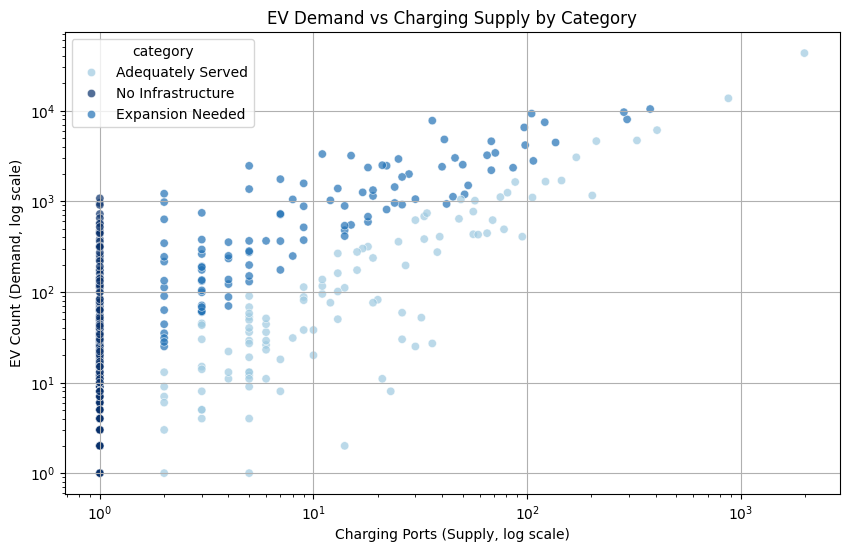

In [72]:
# Demand vs Supply
ev_charging_city_plot = ev_charging_city.copy()

# avoid log(0)
ev_charging_city_plot["total_ports"] = ev_charging_city_plot["total_ports"] + 1

# Blue shades palette
palette = {
    "No Infrastructure": "#08306b",
    "Expansion Needed": "#2171b5",
    "Adequately Served": "#9ecae1"
}

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ev_charging_city_plot,
    x="total_ports",
    y="ev_count",
    hue="category",
    palette=palette,
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("EV Demand vs Charging Supply by Category")
plt.xlabel("Charging Ports (Supply, log scale)")
plt.ylabel("EV Count (Demand, log scale)")

plt.grid(True)
plt.show()

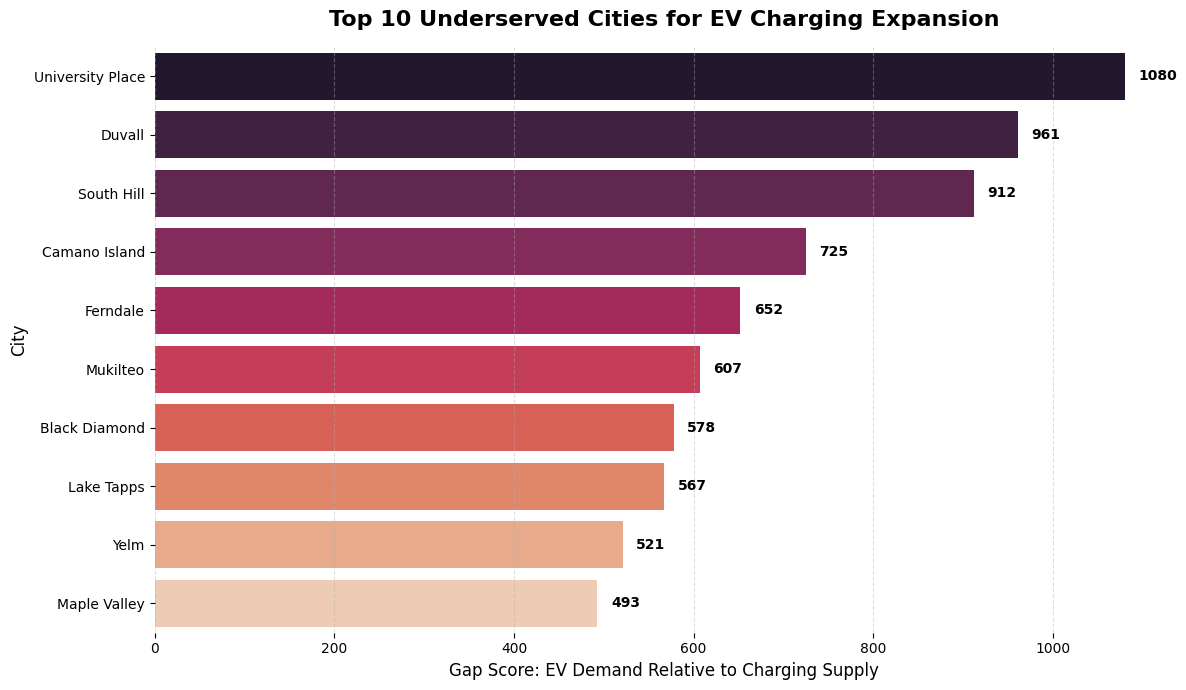

In [73]:
# TOP 10 MOST UNDERSERVED CITIES
top_underserved = ev_charging_city.sort_values("gap_score", ascending=False).head(10)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top_underserved,
    y="city",
    x="gap_score",
    hue="city",
    palette="rocket",
    legend=False
)

# Add value labels
for i, value in enumerate(top_underserved["gap_score"]):
    ax.text(
        value + 15,
        i,
        f"{value:.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Underserved Cities for EV Charging Expansion",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Gap Score: EV Demand Relative to Charging Supply", fontsize=12)
plt.ylabel("City", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

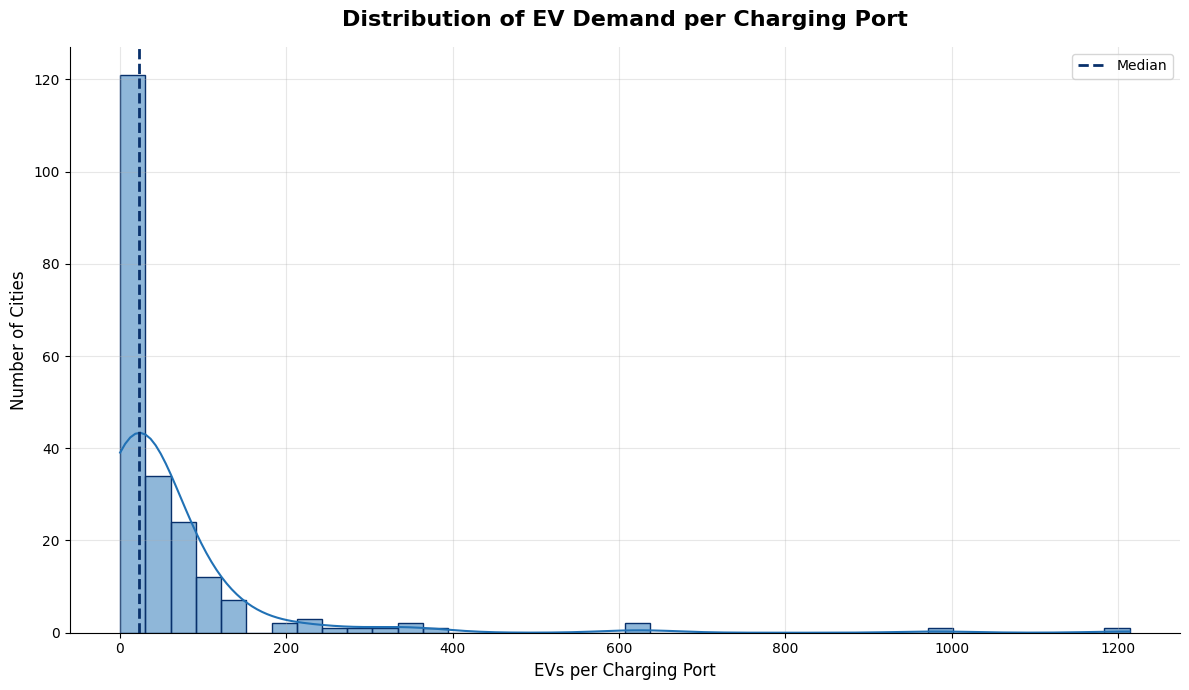

In [75]:
# EVs per Port Distribution
plt.figure(figsize=(12,7))

sns.histplot(
    ev_charging_city["ev_per_port"].dropna(),
    bins=40,
    kde=True,
    color="#2171b5",      # medium blue
    edgecolor="#08306b"   # dark blue edges
)

# Median line (keep contrast but still professional)
plt.axvline(
    ev_charging_city["ev_per_port"].median(),
    color="#08306b",      # dark blue instead of red
    linestyle="--",
    linewidth=2,
    label="Median"
)

plt.title(
    "Distribution of EV Demand per Charging Port",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("EVs per Charging Port", fontsize=12)
plt.ylabel("Number of Cities", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

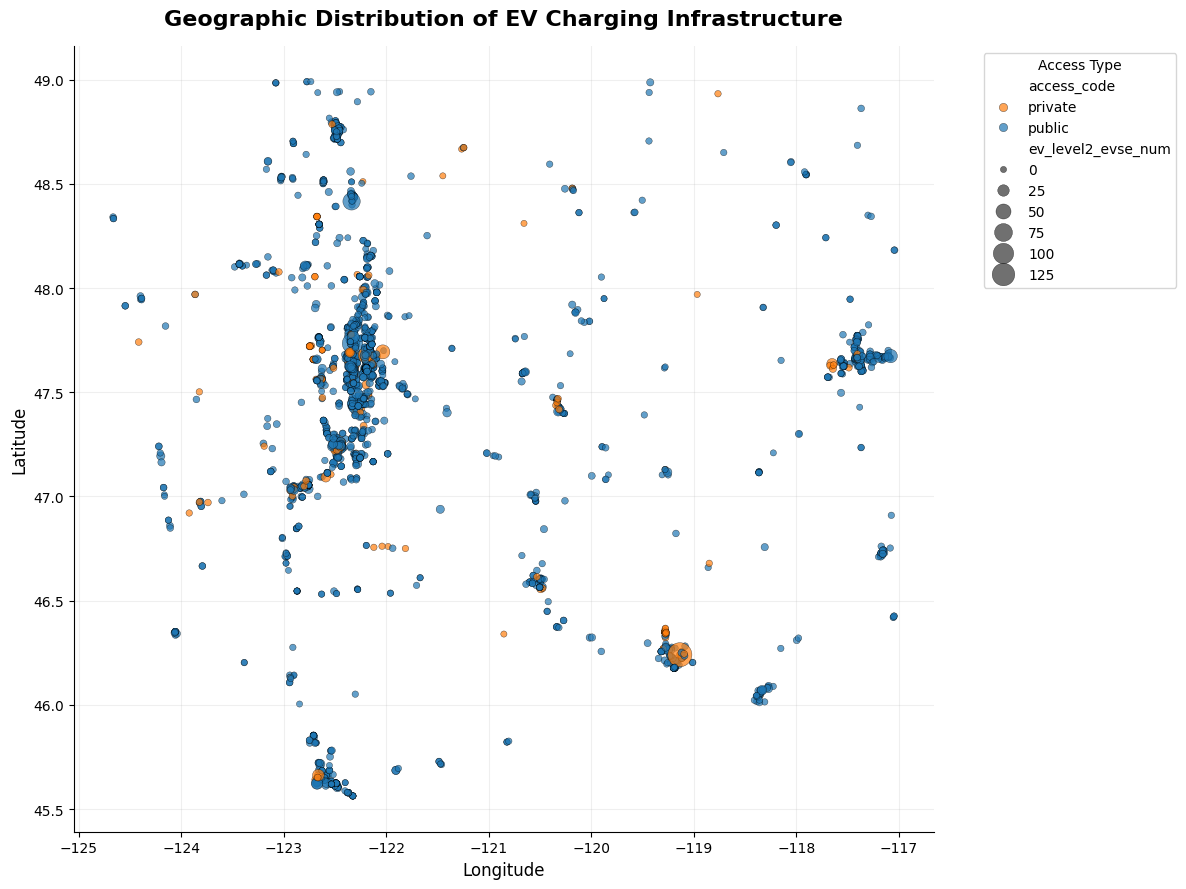

In [76]:
# Map-style Visualization
plt.figure(figsize=(12,9))

sns.scatterplot(
    data=fuel_stations,
    x="longitude",
    y="latitude",
    size="ev_level2_evse_num",
    hue="access_code",
    sizes=(20, 300),
    palette={"public": "#1f77b4", "private": "#ff7f0e"},
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3
)

plt.title(
    "Geographic Distribution of EV Charging Infrastructure",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.grid(alpha=0.2)
sns.despine()

plt.legend(title="Access Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [77]:
top_roi = ev_charging_city.sort_values("gap_score", ascending=False).head(10)

top_roi[["city", "ev_count", "total_ports", "gap_score"]]

,city,ev_count,total_ports,gap_score
457,University Place,1080,0.0,1080.0
117,Duvall,961,0.0,961.0
414,South Hill,912,0.0,912.0
54,Camano Island,725,0.0,725.0
145,Ferndale,652,0.0,652.0
281,Mukilteo,1214,1.0,607.0
34,Black Diamond,578,0.0,578.0
214,Lake Tapps,567,0.0,567.0
497,Yelm,521,0.0,521.0
247,Maple Valley,2465,4.0,493.0


In [78]:
# Regression
import statsmodels.api as sm

# Drop missing values
model_data = ev_charging_city.dropna(subset=["ev_count", "total_ports"])

# Define variables
X = model_data["total_ports"]   # Independent variable
y = model_data["ev_count"]      # Dependent variable

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               ev_count   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     3598.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          9.68e-230
Time:                        19:35:45   Log-Likelihood:                -4056.5
No. Observations:                 499   AIC:                             8117.
Df Residuals:                     497   BIC:                             8125.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         169.5890     37.396      4.535      